In [2]:
from sklearn import linear_model 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd 

In [3]:
data = pd.read_csv("insurance.csv")


X = data.drop(columns= ["charges"]) #input features
y = data["charges"] #output feature

X= pd.get_dummies(X,columns=["region"] , drop_first=True , dtype=int)


X["sex"] = X["sex"].map({"male" : 1 , "female" :0})
X["smoker"] = X["smoker"].map({"yes" :1 , "no": 0})

X["agi_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]


X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 ,random_state= 42)

In [3]:
lasso_model = linear_model.Lasso(alpha=0.5)
lasso_model.fit(X_train,y_train)

,alpha,0.5
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [4]:
y_predict = lasso_model.predict(X_test)

In [ ]:
#evauate (MSE)

mse = mean_squared_error(y_test , y_predict)
print(mse)

20918648.8898256


In [ ]:
#for different lambda (alpha values)

import numpy as np 
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alphas = np.concatenate([
    np.arange(0.1, 5.0, 0.1),   
    np.arange(5, 20, 1),        
    np.arange(20, 100, 5)]).astype(np.float32)
measures = []

for a in alphas :
    model = Lasso(alpha=a)
    model.fit(X_train,y_train)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    measures.append(mse)
    print(f"Mse is for aplha {a} is" , mse)



Mse is for aplha 0.10000000149011612 is 20921803.698431373
Mse is for aplha 0.20000000298023224 is 20921006.729136664
Mse is for aplha 0.30000001192092896 is 20920214.07504108
Mse is for aplha 0.4000000059604645 is 20919427.457715176
Mse is for aplha 0.5 is 20918648.8898256
Mse is for aplha 0.6000000238418579 is 20917870.724086456
Mse is for aplha 0.699999988079071 is 20917099.492198456
Mse is for aplha 0.800000011920929 is 20916337.80425394
Mse is for aplha 0.8999999761581421 is 20915578.805029612
Mse is for aplha 1.0 is 20914832.63508914
Mse is for aplha 1.100000023841858 is 20914090.55193453
Mse is for aplha 1.2000000476837158 is 20913340.211374465
Mse is for aplha 1.2999999523162842 is 20912604.980931815
Mse is for aplha 1.399999976158142 is 20911887.6448218
Mse is for aplha 1.5 is 20911160.683811277
Mse is for aplha 1.600000023841858 is 20910437.147952776
Mse is for aplha 1.7000000476837158 is 20909734.06254454
Mse is for aplha 1.7999999523162842 is 20909036.029915
Mse is for aplh

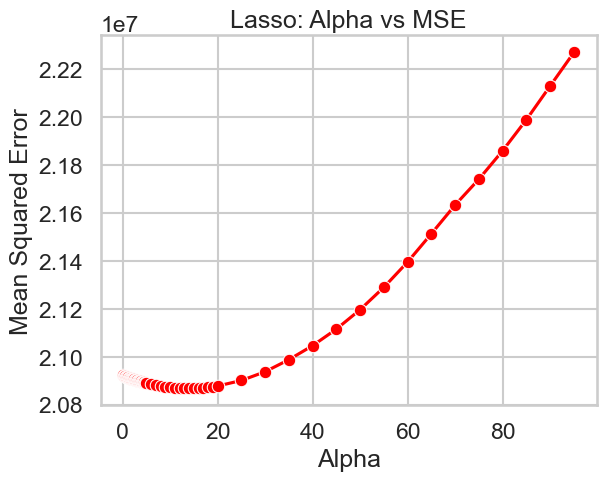

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=alphas,y=measures ,marker="o" ,color= "red")

plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
plt.title("Lasso: Alpha vs MSE")
plt.show()